In [28]:
!pip install tensorflow tensorflow-gpu opencv-python matplotlib PyYAML

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
!wget </content/pretrained-yolov3.h5>
!curl -O </content/pretrained-yolov3.h5>

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `wget </content/pretrained-yolov3.h5>'
/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `curl -O </content/pretrained-yolov3.h5>'


In [54]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.6/876.6 kB 41.9 MB/s eta 0:00:00


In [90]:
from ultralytics import YOLO

# Load YOLO model
yolo_model = YOLO('yolov8n.pt')

Found images: ['/content/images.jpg', '/content/images1.jpg', '/content/images2.jpg', '/content/images3.jpg']

0: 640x480 1 chair, 1 potted plant, 155.8ms
Speed: 4.4ms preprocess, 155.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
Detected 1 results in /content/images.jpg


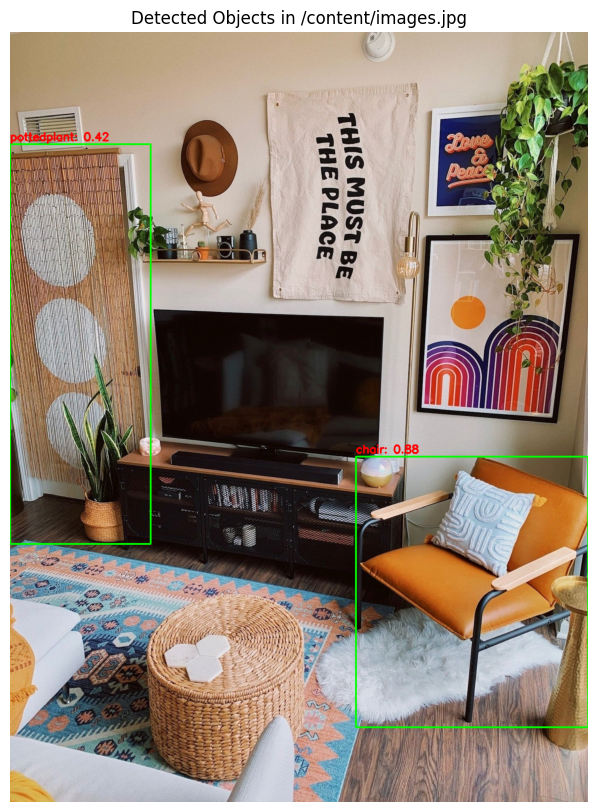


0: 448x640 1 couch, 1 bed, 225.8ms
Speed: 4.4ms preprocess, 225.8ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
Detected 1 results in /content/images1.jpg


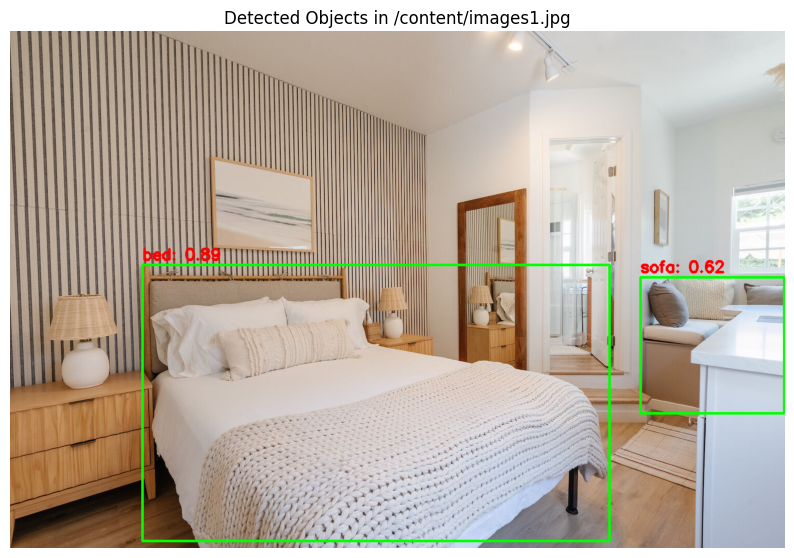


0: 416x640 1 bowl, 2 chairs, 1 couch, 2 potted plants, 1 vase, 214.1ms
Speed: 3.4ms preprocess, 214.1ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
Detected 1 results in /content/images2.jpg


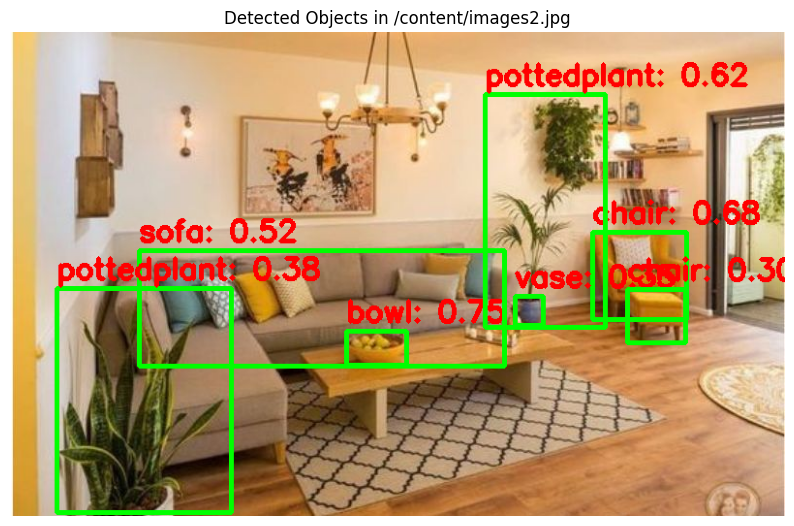


0: 448x640 1 chair, 1 potted plant, 1 tv, 220.0ms
Speed: 3.8ms preprocess, 220.0ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Detected 1 results in /content/images3.jpg


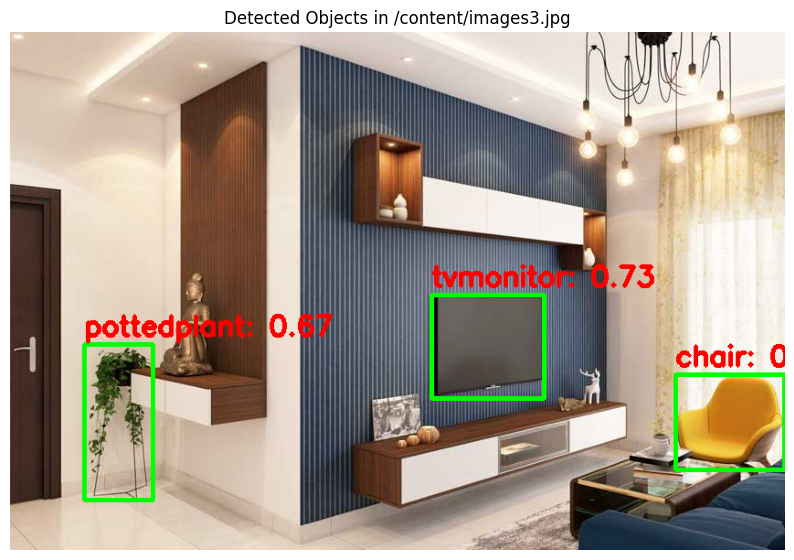

In [98]:
import cv2
import matplotlib.pyplot as plt
import time
import glob
import os

# Load class names
with open('/content/coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# Get image paths
image_paths = glob.glob('/content/*.jpg')
print("Found images:", image_paths)

# Function to detect objects in an image
def detect_objects(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading image: {image_path}")
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = yolo_model.predict(source=image_rgb)

    print(f"Detected {len(results)} results in {image_path}")

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = box.conf[0].cpu().numpy()
            cls = box.cls[0].cpu().numpy()

            if 0 <= int(cls) < len(classes):
                label = f"{classes[int(cls)]}: {conf:.2f}"
            else:
                print(f"Warning: Class ID {int(cls)} not found in coco.names")
                label = f"Class {int(cls)}: {conf:.2f}"

            # Draw bounding box and label
            cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(image_rgb, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)

    return image_rgb

# Create output directory for detected images
output_dir = '/content/output_images1'
os.makedirs(output_dir, exist_ok=True)

# Process images
for img_path in image_paths[:4]:
    detected_image = detect_objects(img_path)
    if detected_image is None:
        continue

    # Save the detected image to output directory
    output_image_path = os.path.join(output_dir, os.path.basename(img_path))
    cv2.imwrite(output_image_path, cv2.cvtColor(detected_image, cv2.COLOR_RGB2BGR))

    # Display detected image
    plt.figure(figsize=(10, 10))
    plt.imshow(detected_image)
    plt.axis('off')
    plt.title(f'Detected Objects in {img_path}')
    plt.show()